In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
!pip install pymc numpyro jax jaxlib

In [66]:
# import libraries
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

# Data Loading and Preprocessing

In [67]:
filepath = "/content/drive/MyDrive/Bayesian Mushroom Classification/mushrooms.csv"

mushroom_df = pd.read_csv(filepath)

mushroom_df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [68]:
def class_label(row):
  if row['class'] == 'e':
    return 0
  else:
    return 1

mushroom_df['poisonous'] = mushroom_df.apply(class_label, axis = 1)

In [69]:
features = ['cap-surface', 'gill-color', 'odor', 'ring-number',
            'spore-print-color', 'stalk-surface-above-ring',
            'veil-color']

In [70]:
oe = OrdinalEncoder()
mushroom_df[features] = oe.fit_transform(mushroom_df[features])

In [71]:
le = LabelEncoder()
y = le.fit_transform(mushroom_df['poisonous'])

In [72]:
#num_predictors = X.shape[1]

In [73]:
#mushroom_df['habitat_idx'] = le.fit_transform(mushroom_df['habitat'])
#mushroom_df['habitat_idx'].head()

In [74]:
#mushroom_df['habitat'].value_counts()

In [75]:
#habitat_idx = mushroom_df['habitat_idx'].values
#habitat_idx

In [76]:
#num_habitats = mushroom_df['habitat'].nunique()

# Mathematical Model & NIMBLE Analysis

In [77]:
with pm.Model() as mushroom_model:
  beta_0 = pm.Normal('beta_0', mu = 0 , sigma = 10)
  beta_cap = pm.Normal('beta_cap', mu = 0, sigma = 10)
  beta_gill = pm.Normal('beta_gill', mu = 0, sigma = 10)
  beta_odor = pm.Normal('beta_odor', mu = 0, sigma = 10)
  beta_ring = pm.Normal('beta_ring', mu = 0, sigma = 10)
  beta_spore = pm.Normal('beta_spore', mu = 0, sigma = 10)
  beta_stalk = pm.Normal('beta_stalk', mu = 0, sigma = 10)
  beta_veil = pm.Normal('beta_veil', mu = 0, sigma = 10)

  sigma_habitat = pm.HalfNormal('sigma_habitat', sigma = 10)
  beta_grasses = pm.Normal('beta_grasses', mu = 0, sigma = 10)
  beta_paths = pm.Normal('beta_paths', mu = 0, sigma = 10)
  beta_leaves = pm.Normal('beta_leaves', mu = 0, sigma = 10)
  beta_meadows = pm.Normal('beta_meadows', mu = 0, sigma = 10)
  beta_urban = pm.Normal('beta_urban', mu = 0, sigma = 10)
  beta_waste = pm.Normal('beta_waste', mu = 0, sigma = 10)
  beta_woods = pm.Normal('beta_woods', mu = 0, sigma = 10)

  is_grasses = (mushroom_df['habitat'] == 'g').astype(int).values
  is_paths = (mushroom_df['habitat'] == 'p').astype(int).values
  is_leaves = (mushroom_df['habitat'] == 'l').astype(int).values
  is_meadows = (mushroom_df['habitat'] == 'm').astype(int).values
  is_urban = (mushroom_df['habitat'] == 'u').astype(int).values
  is_waste = (mushroom_df['habitat'] == 'w').astype(int).values
  is_woods = (mushroom_df['habitat'] == 'd').astype(int).values

  linear_predictor = (beta_0 + beta_cap * mushroom_df['cap-surface'] +
                      beta_gill * mushroom_df['gill-color'] +
                      beta_odor * mushroom_df['odor'] +
                      beta_ring * mushroom_df['ring-number'] +
                      beta_spore * mushroom_df['spore-print-color'] +
                      beta_stalk * mushroom_df['stalk-surface-above-ring'] +
                      beta_veil * mushroom_df['veil-color'] +
                       (beta_grasses * sigma_habitat * is_grasses) +
                      (beta_paths * sigma_habitat * is_paths) +
                       (beta_leaves * sigma_habitat * is_leaves) +
                      (beta_meadows * sigma_habitat * is_meadows) +
                       (beta_urban * sigma_habitat * is_urban) +
                      (beta_waste * sigma_habitat * is_waste) +
                       (beta_woods * sigma_habitat * is_woods))

  p = pm.math.invlogit(linear_predictor)
  y_obs = pm.Bernoulli('y_obs', p = p, observed = y)

  trace = pm.sample(draws = 500,
                    tune = 500,
                    chains = 3,
                    return_inferencedata = True,
                    nuts_sampler = 'numpyro')


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [78]:
sdsdsd

NameError: name 'sdsdsd' is not defined

# Convergence Testing & TracePlots

Generating Trace and Density Plots


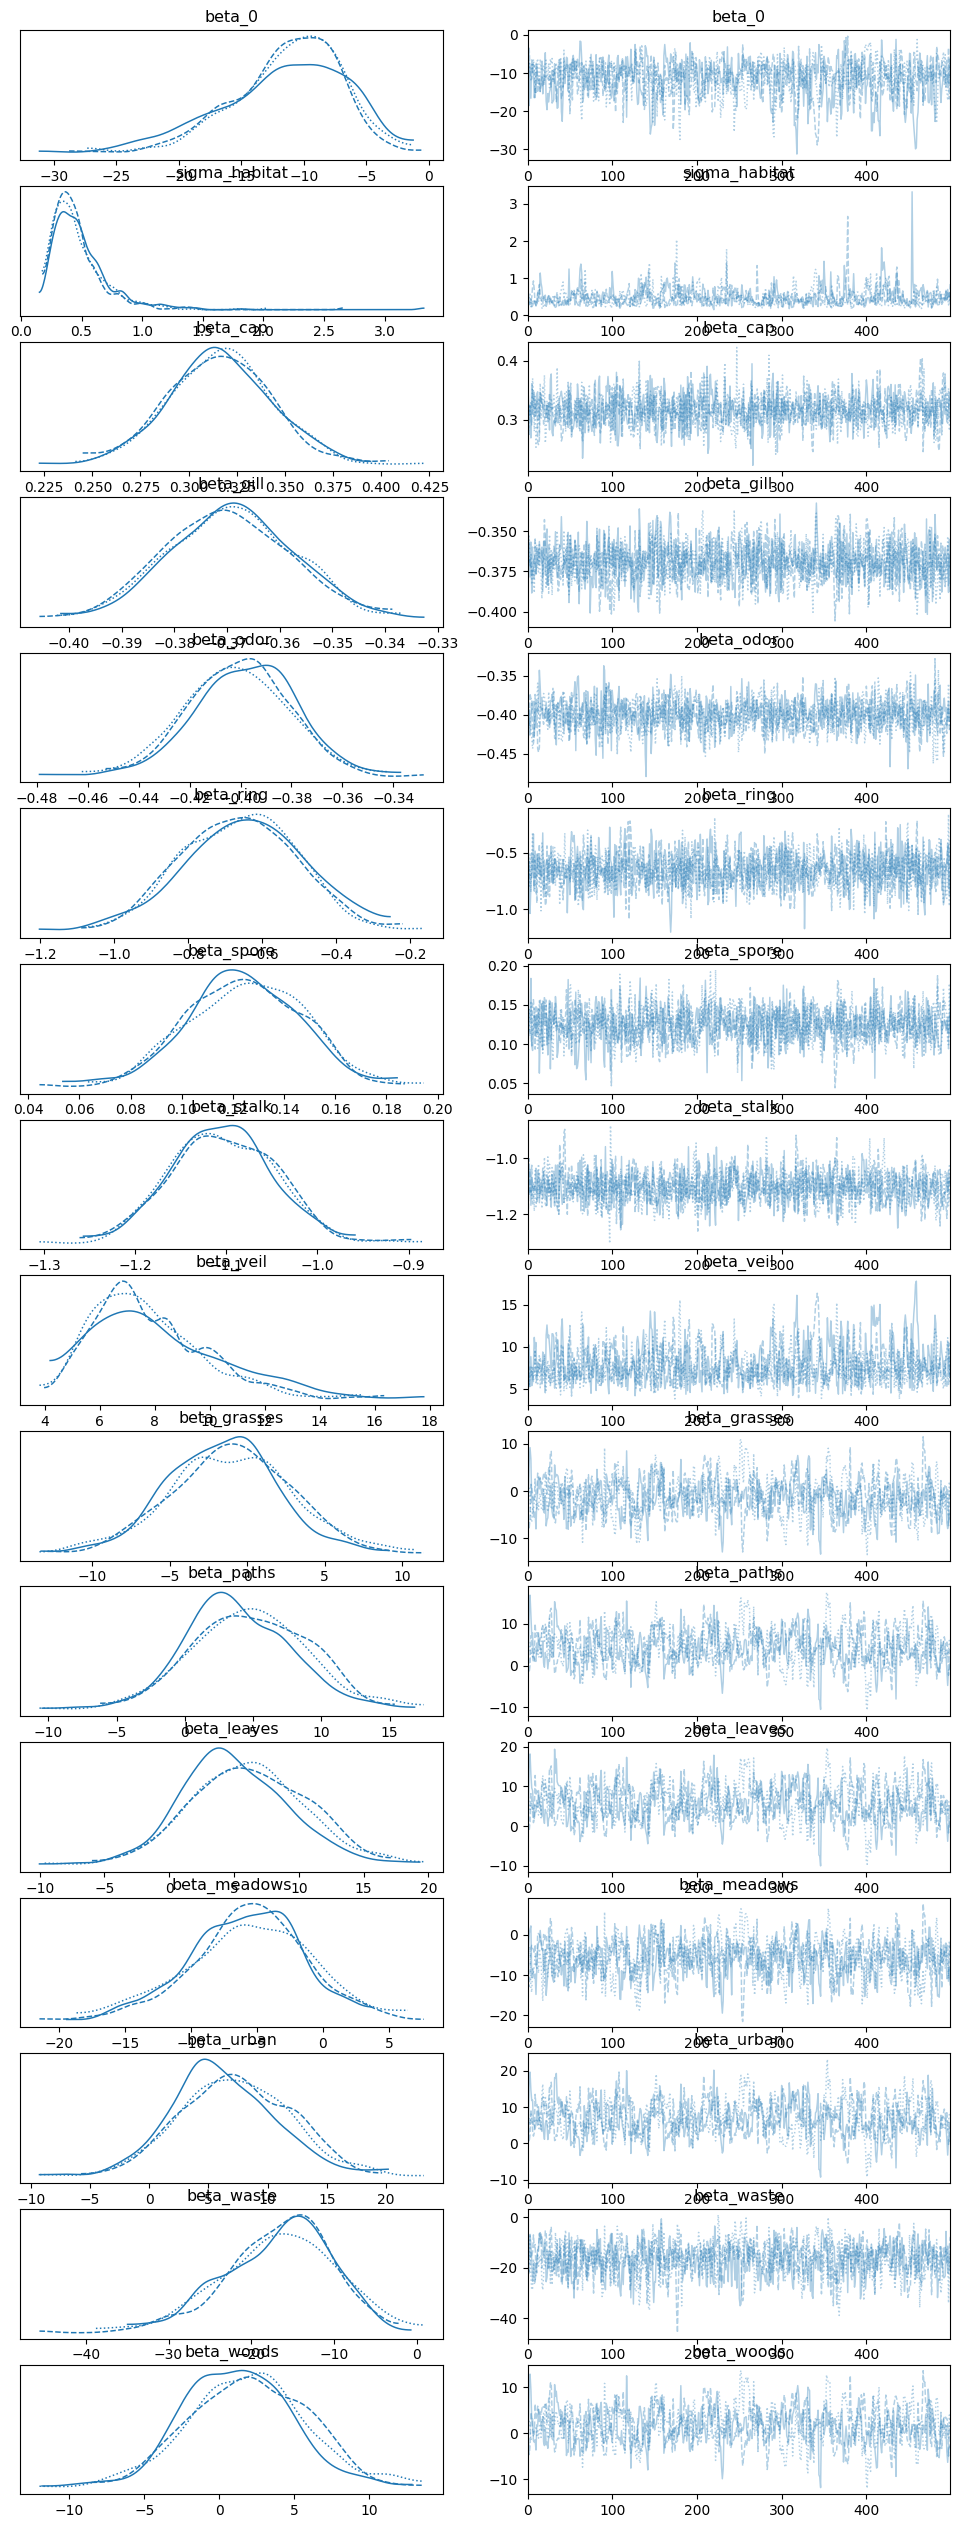

In [83]:
print("Generating Trace and Density Plots")
az.plot_trace(trace, var_names = ['beta_0', 'sigma_habitat',
                                  'beta_cap', 'beta_gill', 'beta_odor',
                                  'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                  'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                  'beta_urban', 'beta_waste', 'beta_woods']);

In [80]:
# check Gelman-Rubin Diagnostic
summary_stats = az.summary(trace, var_names = ['beta_0', 'sigma_habitat',
                                               'beta_cap', 'beta_gill', 'beta_odor',
                                               'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                               'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                               'beta_urban', 'beta_waste', 'beta_woods'])
print(summary_stats[['mean', 'sd', 'r_hat', 'ess_bulk']])

                 mean     sd  r_hat  ess_bulk
beta_0        -11.473  4.709   1.01     588.0
sigma_habitat   0.477  0.238   1.00     385.0
beta_cap        0.316  0.027   1.00    1521.0
beta_gill      -0.369  0.012   1.00    1649.0
beta_odor      -0.400  0.020   1.00    1067.0
beta_ring      -0.655  0.158   1.00    1723.0
beta_spore      0.125  0.023   1.00    1233.0
beta_stalk     -1.104  0.056   1.00    1378.0
beta_veil       7.903  2.205   1.01     732.0
beta_grasses   -1.240  3.875   1.01     403.0
beta_paths      4.463  4.183   1.01     308.0
beta_leaves     5.734  4.432   1.01     307.0
beta_meadows   -5.748  4.489   1.01     488.0
beta_urban      6.926  4.658   1.01     299.0
beta_waste    -16.684  6.527   1.00     686.0
beta_woods      1.681  3.887   1.01     344.0


/usr/local/lib/python3.12/dist-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (48) in plot_autocorr, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'beta_0\n0'}>,
        <Axes: title={'center': 'beta_0\n1'}>,
        <Axes: title={'center': 'beta_0\n2'}>,
        <Axes: title={'center': 'sigma_habitat\n0'}>],
       [<Axes: title={'center': 'sigma_habitat\n1'}>,
        <Axes: title={'center': 'sigma_habitat\n2'}>,
        <Axes: title={'center': 'beta_cap\n0'}>,
        <Axes: title={'center': 'beta_cap\n1'}>],
       [<Axes: title={'center': 'beta_cap\n2'}>,
        <Axes: title={'center': 'beta_gill\n0'}>,
        <Axes: title={'center': 'beta_gill\n1'}>,
        <Axes: title={'center': 'beta_gill\n2'}>],
       [<Axes: title={'center': 'beta_odor\n0'}>,
        <Axes: title={'center': 'beta_odor\n1'}>,
        <Axes: title={'center': 'beta_odor\n2'}>,
        <Axes: title={'center': 'beta_ring\n0'}>],
       [<Axes: title={'center': 'beta_ring\n1'}>,
        <Axes: title={'center': 'beta_ring\n2'}>,
        <Axes: title={'center': 'beta_spore\n0'}>,
        <Axes: title={'center': 'beta_spore\n

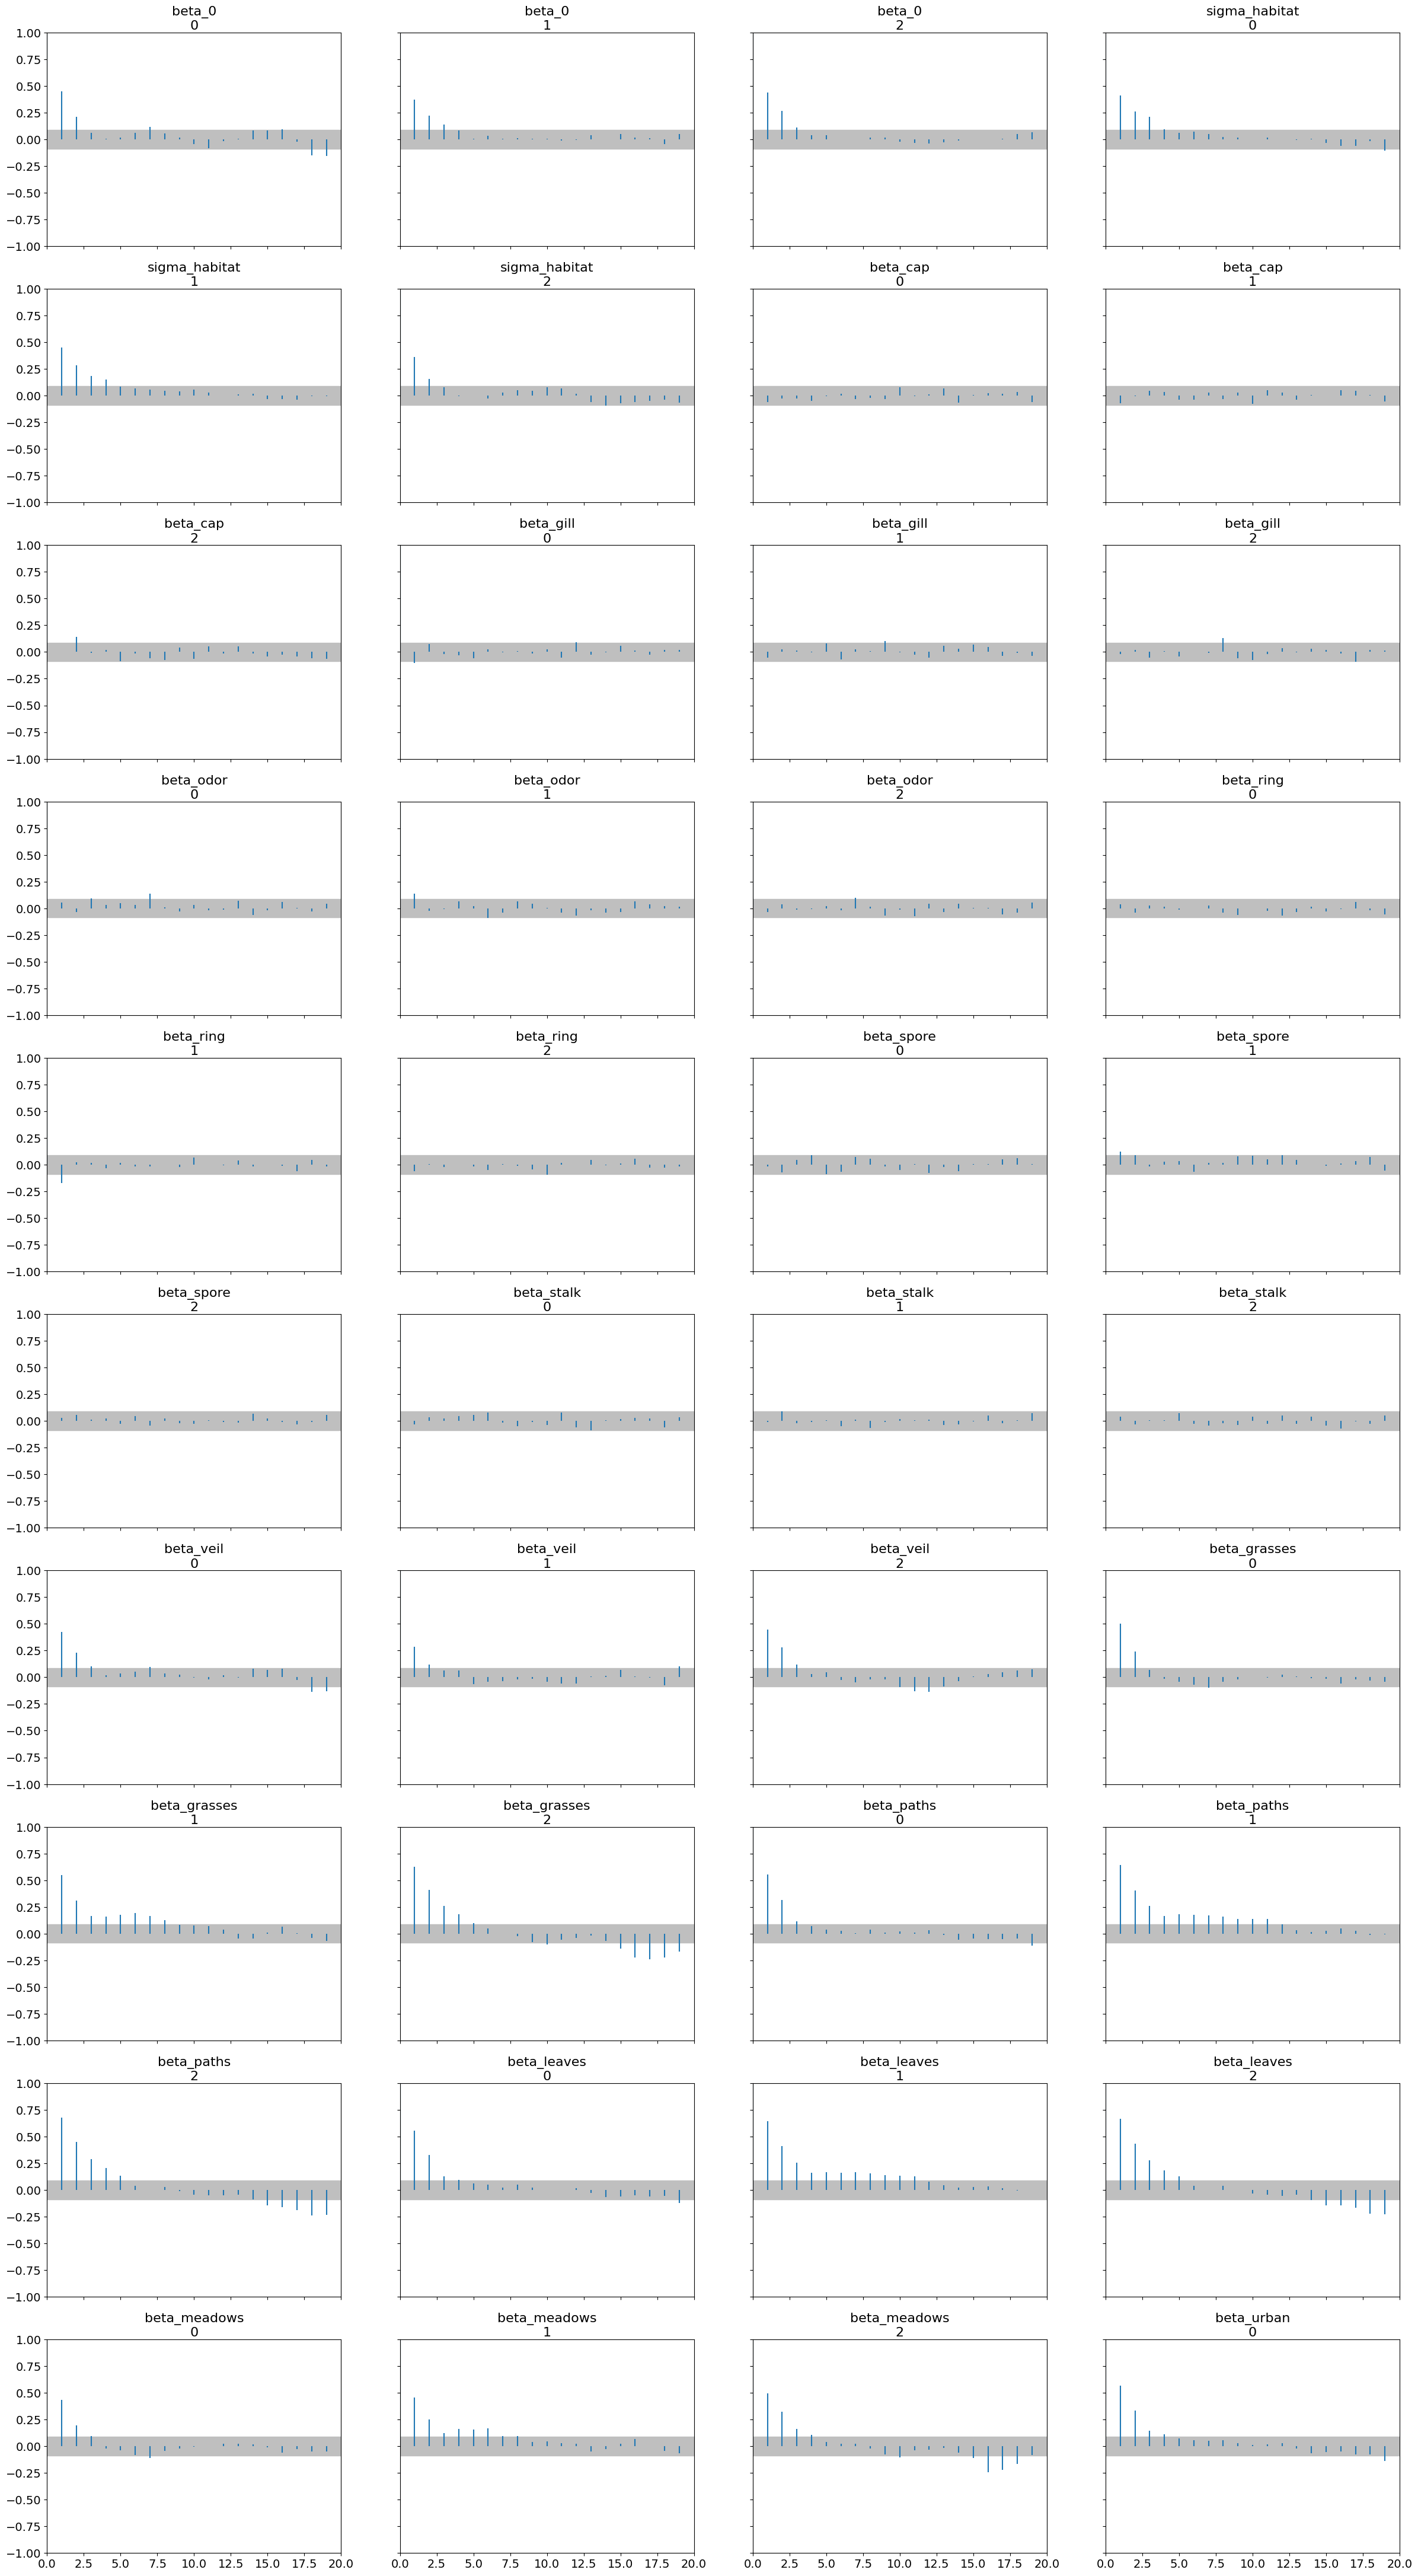

In [82]:
# check for the high autocorrelation
az.plot_autocorr(trace, var_names = ['beta_0', 'sigma_habitat',
                                      'beta_cap', 'beta_gill', 'beta_odor',
                                      'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                      'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                      'beta_urban', 'beta_waste', 'beta_woods'], max_lag = 20)


# Posterior Predictive Checks

In [84]:
with mushroom_model:
  posterior_predictive = pm.sample_posterior_predictive(trace)

Output()

<Axes: xlabel='y_obs'>

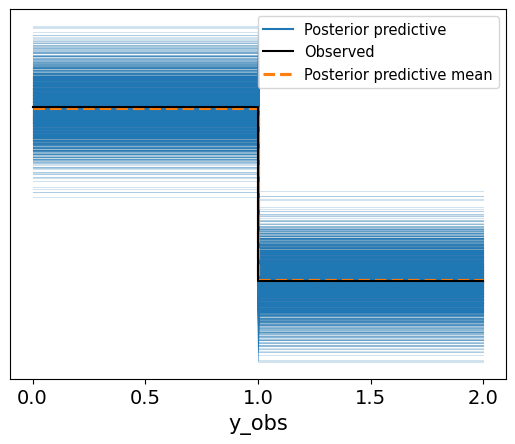

In [85]:
az.plot_ppc(posterior_predictive, kind = "kde")

In [90]:
clean_features = summary_stats.drop(['beta_0', 'sigma_habitat'], errors='ignore')
odds_ratios = np.exp(clean_features['mean'])

poster_table = pd.DataFrame({
    'Log-Odds (Beta)': clean_features['mean'],
    'Odds Ratio': odds_ratios})
print(poster_table)

              Log-Odds (Beta)    Odds Ratio
beta_cap                0.316  1.371630e+00
beta_gill              -0.369  6.914254e-01
beta_odor              -0.400  6.703200e-01
beta_ring              -0.655  5.194421e-01
beta_spore              0.125  1.133148e+00
beta_stalk             -1.104  3.315423e-01
beta_veil               7.903  2.705386e+03
beta_grasses           -1.240  2.893842e-01
beta_paths              4.463  8.674736e+01
beta_leaves             5.734  3.092036e+02
beta_meadows           -5.748  3.189153e-03
beta_urban              6.926  1.018412e+03
beta_waste            -16.684  5.678464e-08
beta_woods              1.681  5.370924e+00
